PREPARING PROSSES

In [ ]:
!nvidia-smi

In [ ]:
!pip install ultralytics

EXTRACT DATA

In [ ]:
import zipfile
!unzip  /content/dataset.zip -d /content/data

SEGMEN_TRAIN

In [ ]:
!yolo task=segment mode=train data=/content/data/dataset/dataset.yaml model=yolo11n-seg.pt epochs=10 imgsz=640

/bin/bash: line 1: yolo: command not found


In [ ]:
# prompt: /bin/bash: line 1: yolo: command not found

import zipfile
# PREPARING PROSSES
!nvidia-smi
!pip install ultralytics
# EXTRACT DATA
!unzip  /content/dataset.zip -d /content/data
# SEGMEN_TRAIN
!yolo task=segment mode=train data=/content/data/dataset/dataset.yaml model=yolov8n-seg.pt epochs=10 imgsz=640

Mon May 26 13:52:30 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# EXTRACT DATA
!unzip  /content/dataset.zip -d /content/data
# SEGMEN_TRAIN
!yolo task=segment mode=train data=/content/data/dataset/dataset.yaml model=yolov8n-seg.pt epochs=10 imgsz=640

TRAIN_VALIDATION

In [ ]:
!yolo task=segment mode=predict model=runs/segment/train/weights/best.pt source=/content/data/dataset/val/images save=True conf=0.2 imgsz=640

Ultralytics 8.3.145 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLOv8n-seg summary (fused): 85 layers, 3,404,320 parameters, 0 gradients, 12.6 GFLOPs

image 1/22 /content/data/dataset/val/images/LeeHi_-_ONLY_Official_MV_ENG_CHN_frame_00004.png: 384x640 1 car, 1 train, 51.6ms
image 2/22 /content/data/dataset/val/images/LeeHi_-_ONLY_Official_MV_ENG_CHN_frame_00005.png: 384x640 1 car, 1 train, 8.1ms
image 3/22 /content/data/dataset/val/images/LeeHi_-_ONLY_Official_MV_ENG_CHN_frame_00006.png: 384x640 1 person, 1 train, 7.9ms
image 4/22 /content/data/dataset/val/images/LeeHi_-_ONLY_Official_MV_ENG_CHN_frame_00012.png: 384x640 3 persons, 7.8ms
image 5/22 /content/data/dataset/val/images/LeeHi_-_ONLY_Official_MV_ENG_CHN_frame_00015.png: 384x640 (no detections), 7.7ms
image 6/22 /content/data/dataset/val/images/LeeHi_-_ONLY_Official_MV_ENG_CHN_frame_00018.png: 384x640 2 persons, 7.6ms
image 7/22 /content/data/dataset/val/images/LeeHi_-_ONLY_Official_MV_ENG_CHN_frame_00024.p

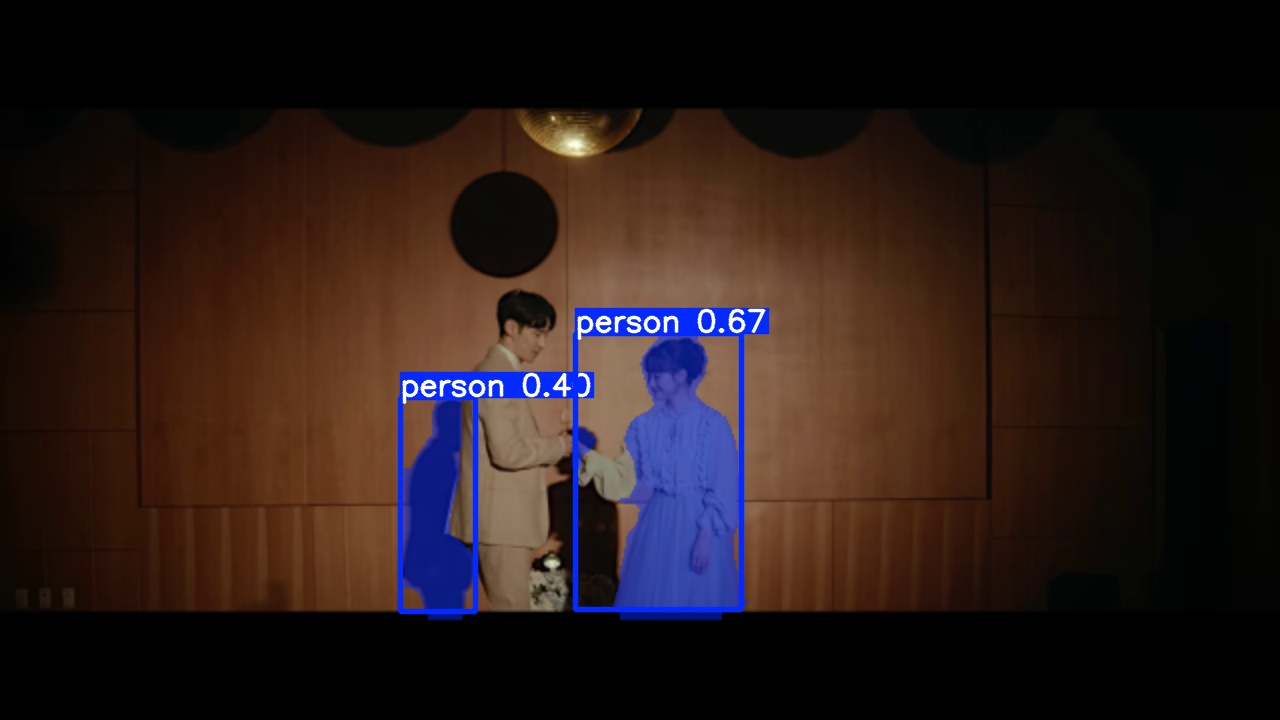

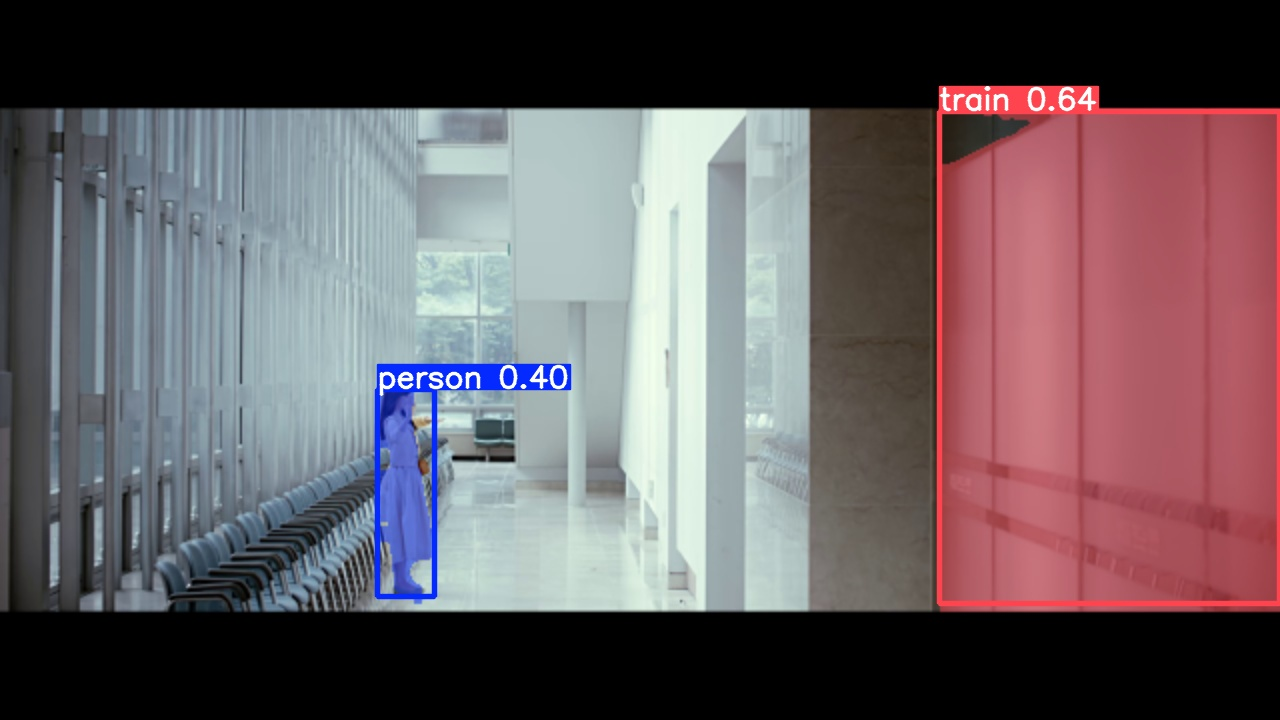

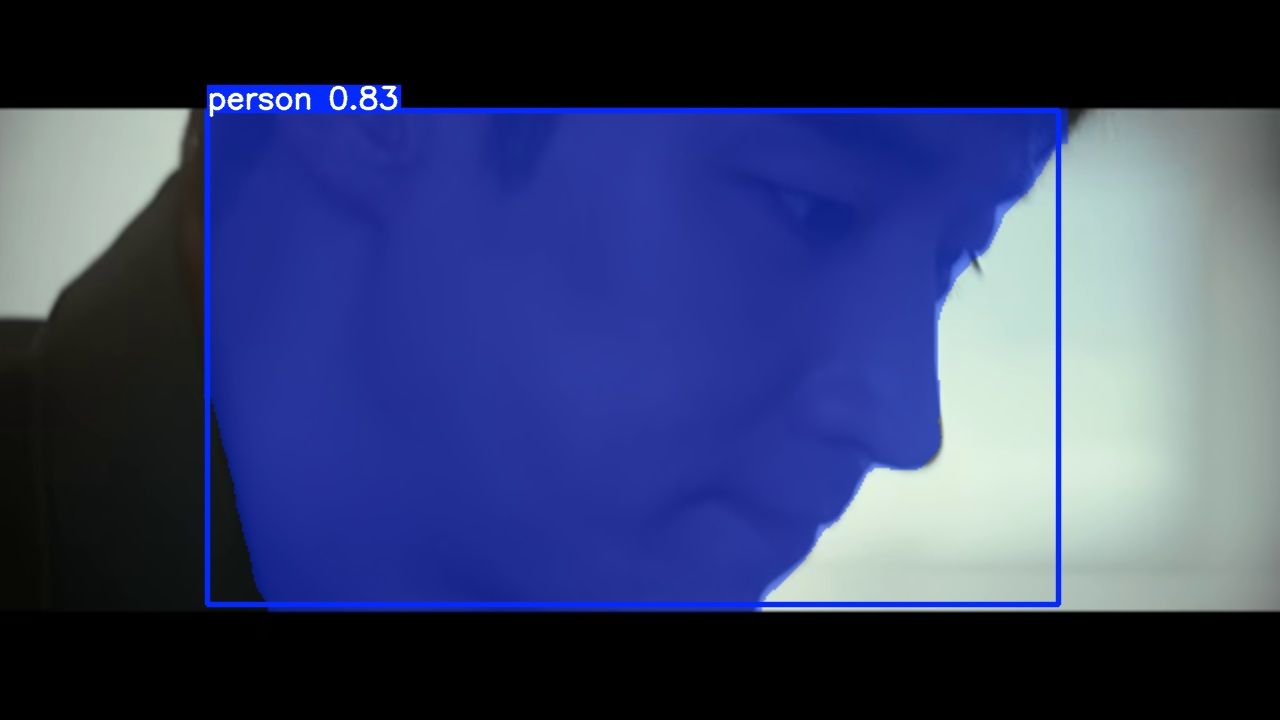

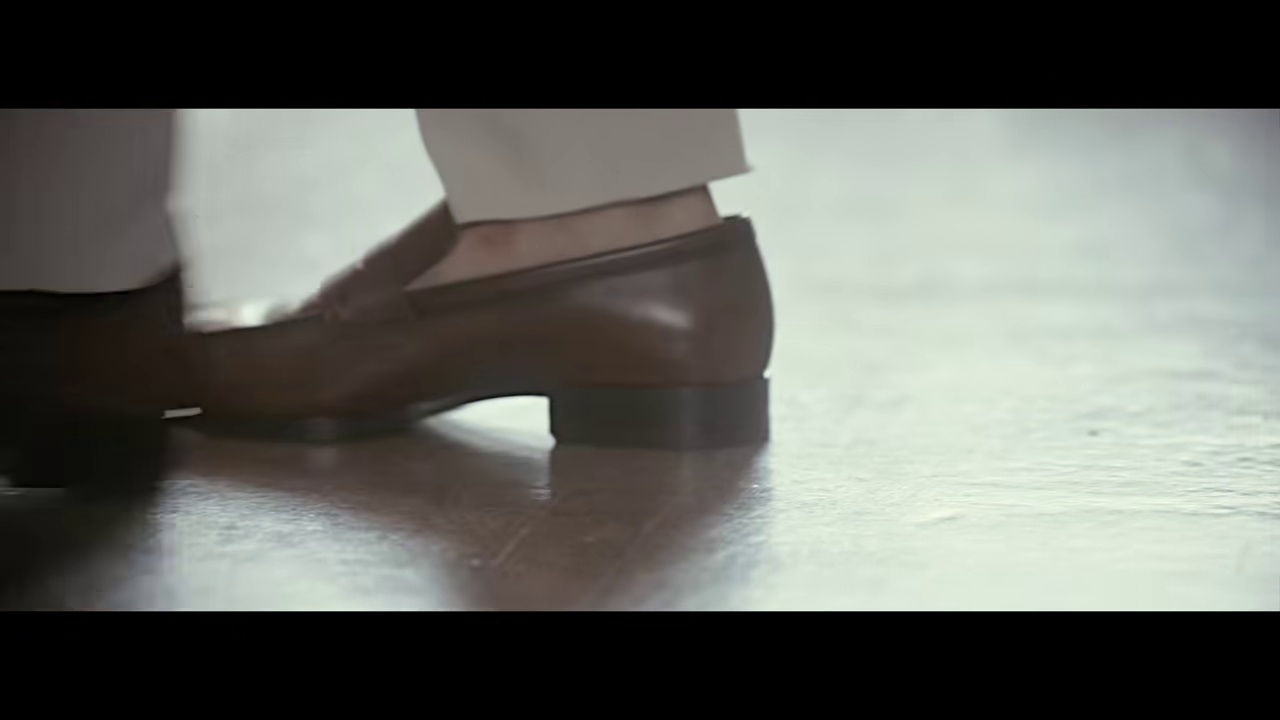

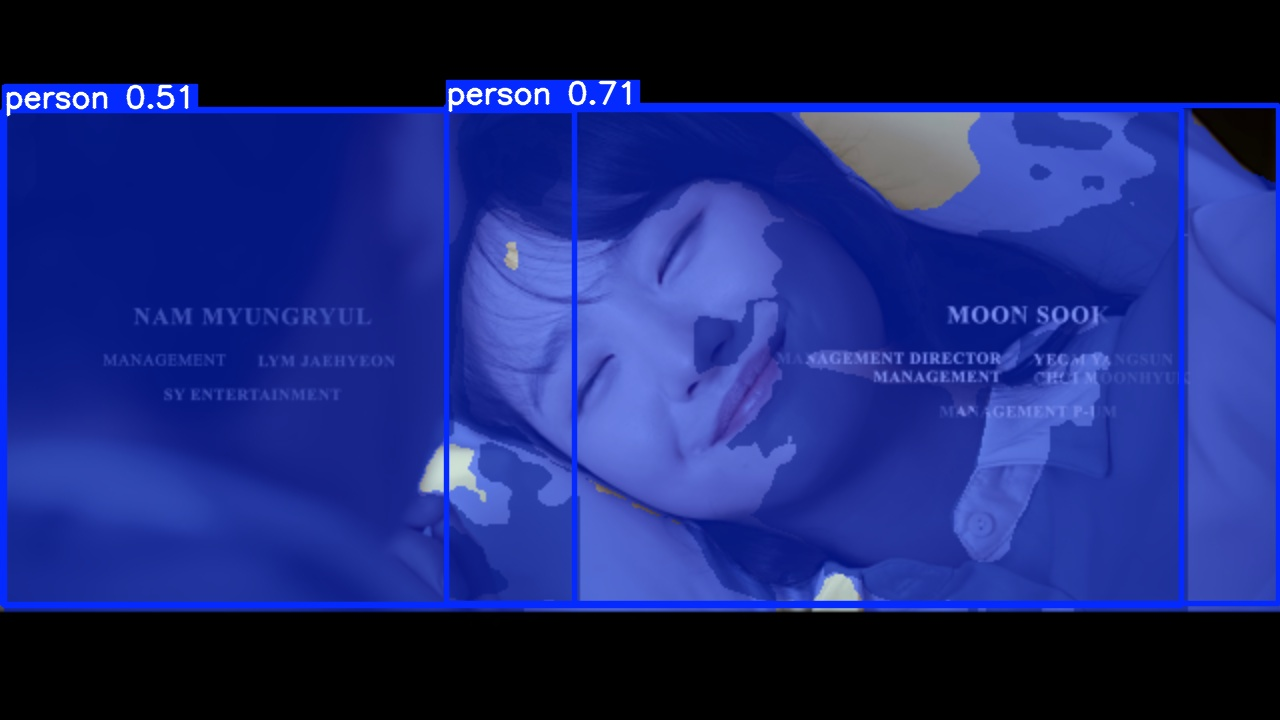

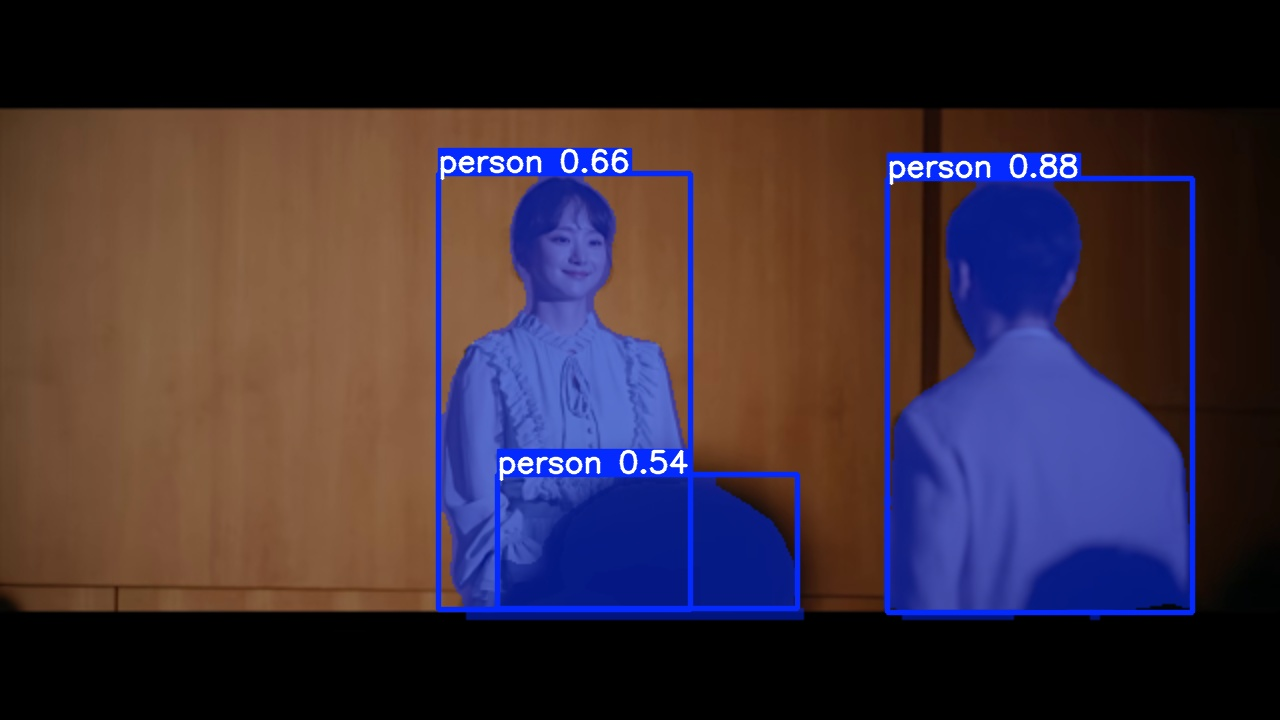

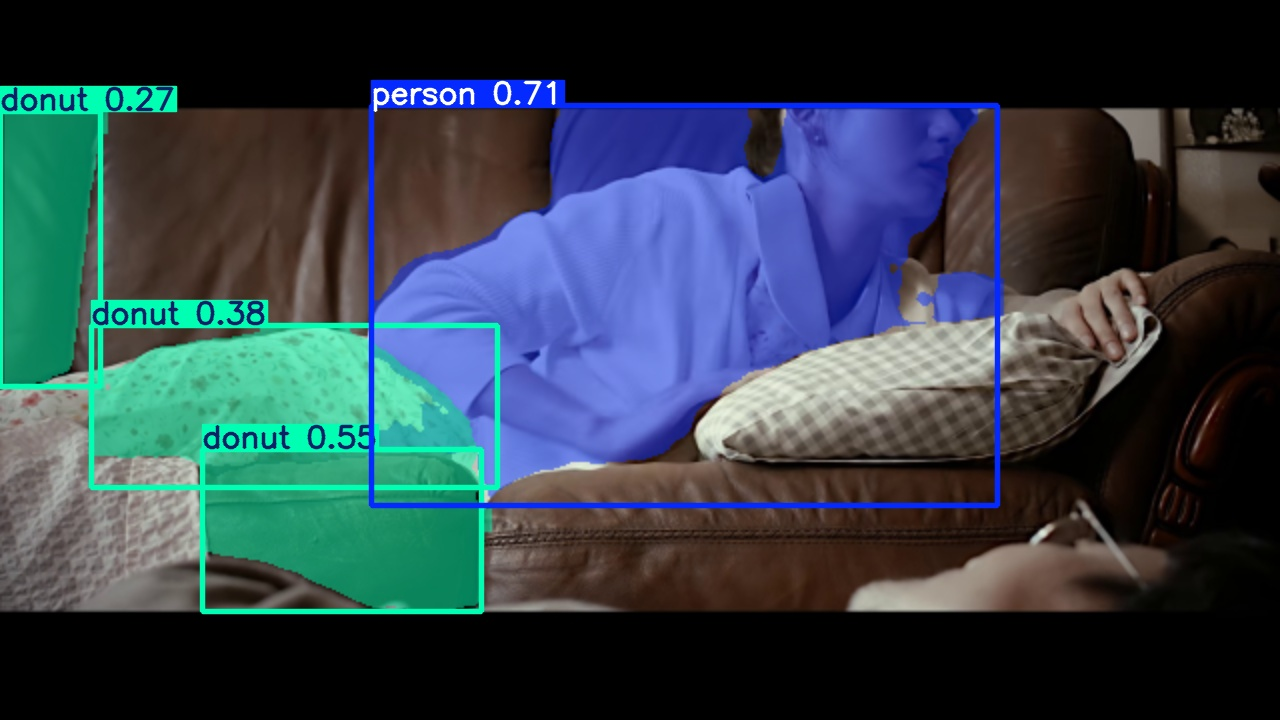

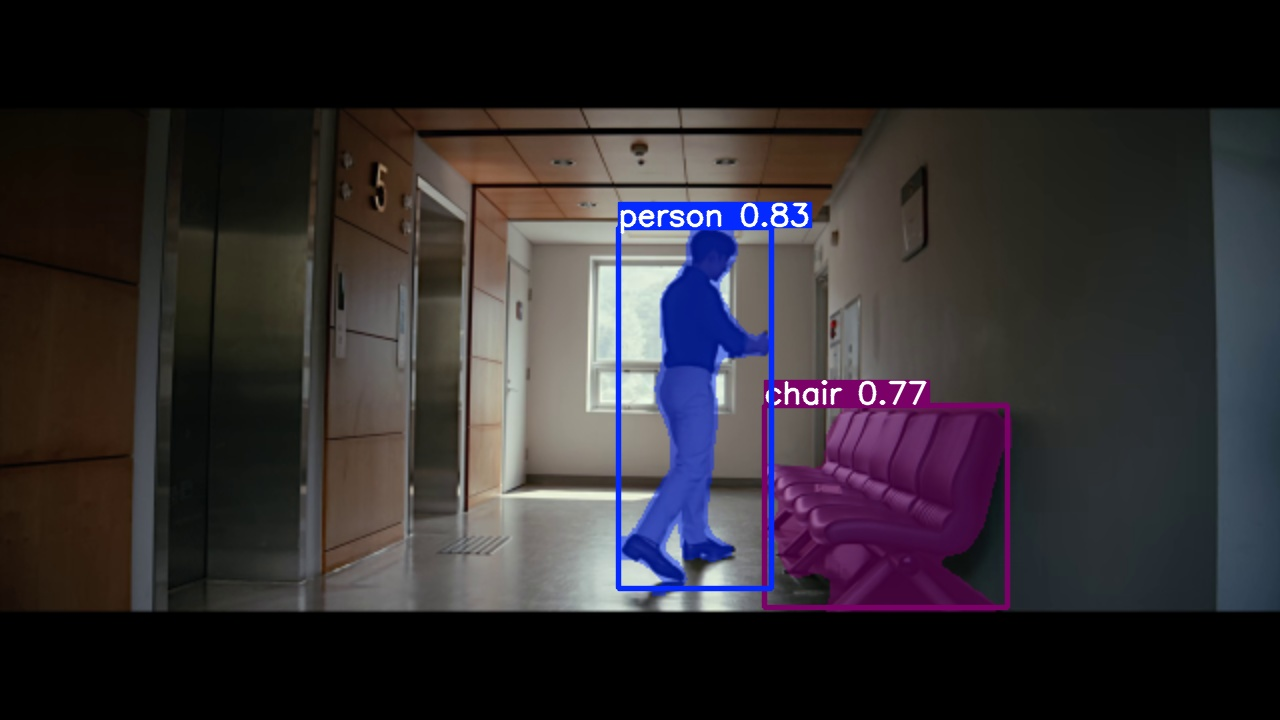

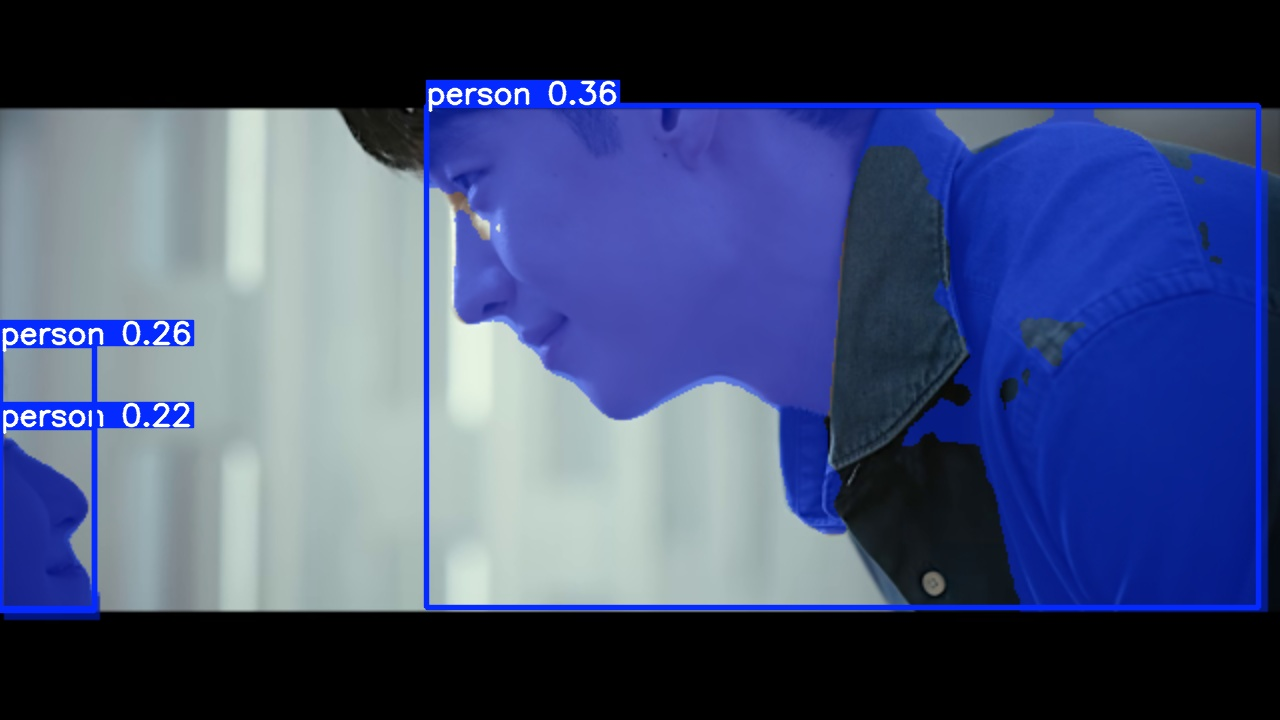

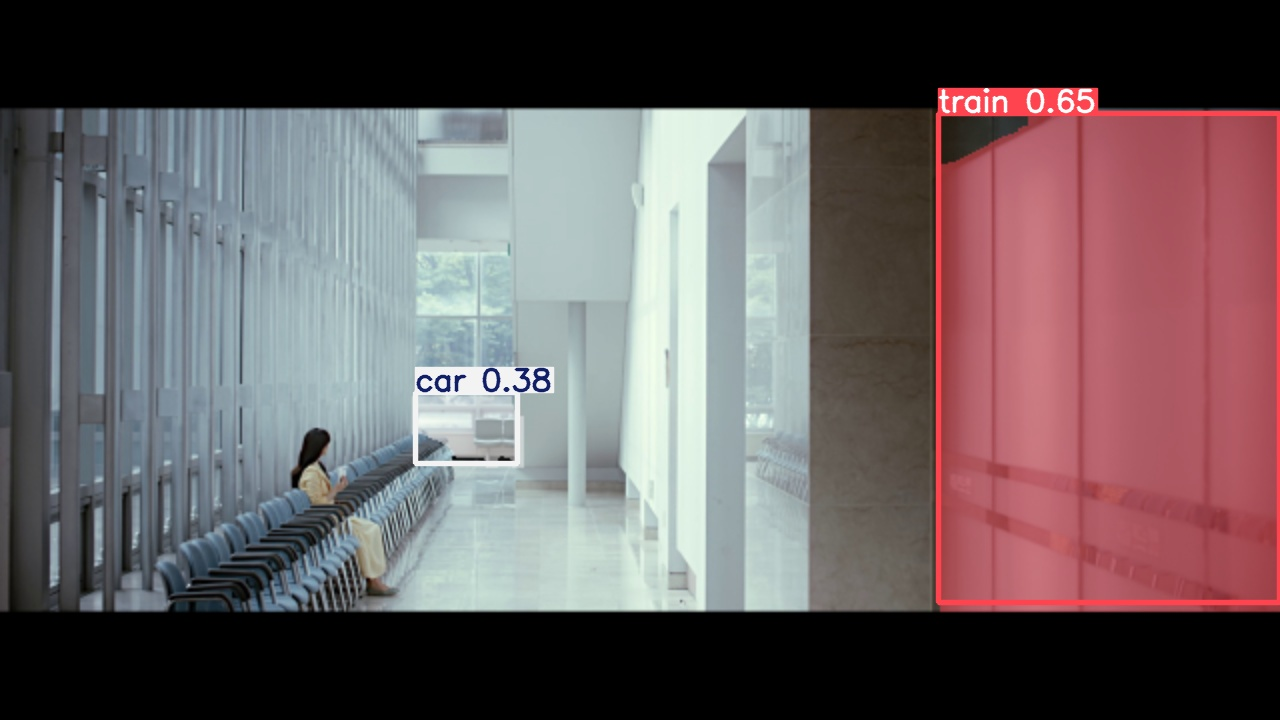

In [ ]:
import glob
from IPython.display import Image, display
for image_path in glob.glob(f'/content/runs/segment/predict/*.jpg')[:10]:
  display(Image(filename=image_path, height=400))
  print('\n')


Download YOLO Model

In [ ]:
# Create "my_model" folder to store model weights and train results
!mkdir /content/my_model
!cp /content/runs/segment/train/weights/best.pt /content/my_model/my_model.pt
!cp -r /content/runs/segment/train /content/my_model

# Zip into "my_model.zip"
%cd my_model
!zip /content/my_model.zip my_model.pt
!zip -r /content/my_model.zip train
%cd /content

In [ ]:
# This takes forever for some reason, you can also just download the model from the sidebar
from google.colab import files

files.download('/content/my_model.zip')